--- CALCULANDO CURVA DE APRENDIZAJE (F1-SCORE) ---
Este proceso puede tardar varios minutos. Por favor, espera...



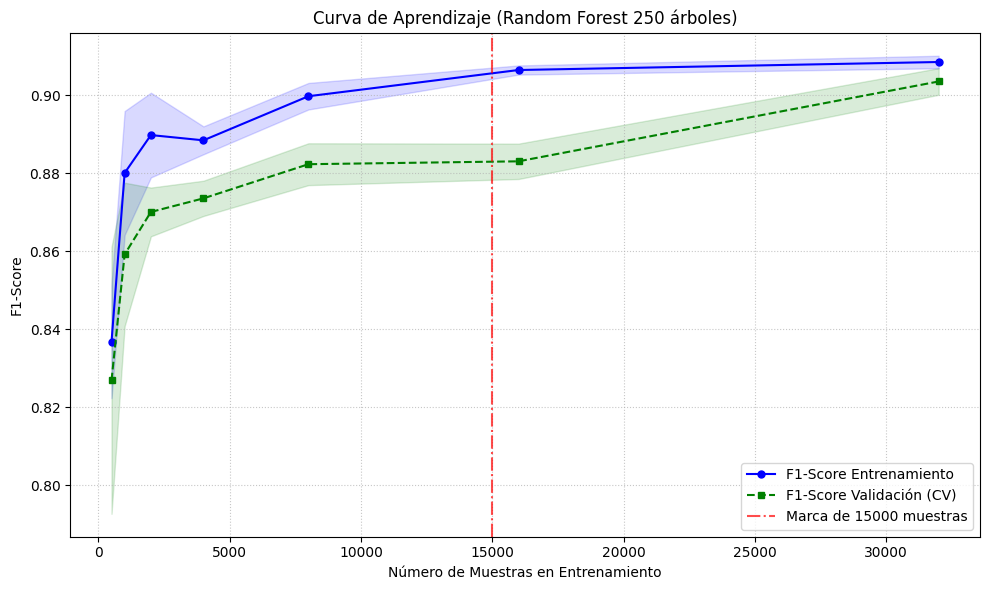

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

print("--- CALCULANDO CURVA DE APRENDIZAJE (F1-SCORE) ---")
print("Este proceso puede tardar varios minutos. Por favor, espera...\n")

# 1. Cargar datos (ajusta la ruta si es necesario)
df_gen = pd.read_csv('../../Datos/df_general.csv')

# Mapear target a binario (Spoof = 1, la clase que nos importa para el F1)
df_gen['y'] = df_gen['Key'].map({'bonafide': 0, 'spoof': 1})

# Separar X e y
drop_columns = ['Key', 'file_name', 'User_ID', 'Spoofing_ID', 'y']
X = df_gen.drop(columns=drop_columns, errors='ignore')
y = df_gen['y']

# 2. Definir el Pipeline (Undersampling + Modelo Simplificado de 250 árboles)
pipeline = ImbPipeline([
    ('undersampling', RandomUnderSampler(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1))
])

# 3. Configurar Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definimos los tamaños de entrenamiento absolutos que queremos probar.
# Ponemos focos en los valores bajos (500, 1000, 2000, 4000...) para ver cuándo hace el "codo" (plateau)
tamanos_a_probar = np.array([500, 1000, 2000, 4000, 8000, 16000, 32000])

# 4. Calcular la Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    train_sizes=tamanos_a_probar,
    cv=cv,
    scoring='f1', # Evaluamos F1-Score (por defecto mira la clase 1, 'spoof')
    n_jobs=-1     # Usa todos los núcleos disponibles
)

# Calcular medias y desviaciones estándar
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 5. Graficar la Curva de Aprendizaje
plt.figure(figsize=(10, 6))

# Línea de Entrenamiento (Suele empezar alta e ir bajando)
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='F1-Score Entrenamiento')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

# Línea de Validación/Test (Suele empezar baja e ir subiendo hasta estabilizarse)
plt.plot(train_sizes, test_mean, color='green', marker='s', markersize=5, linestyle='--', label='F1-Score Validación (CV)')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

# Detalles visuales
plt.title('Curva de Aprendizaje (Random Forest 250 árboles)')
plt.xlabel('Número de Muestras en Entrenamiento')
plt.ylabel('F1-Score')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower right')

# Añadir una línea vertical en 2000 para ver cómo se comporta en ese punto exacto
plt.axvline(x=15000, color='red', linestyle='-.', alpha=0.7, label='Marca de 15000 muestras')
plt.legend()

plt.tight_layout()
plt.show()